# Imports & Dataset Loading

In [4]:
import numpy as np

In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
import nltk

In [9]:
import string

In [10]:
from collections import Counter

In [11]:
from wordcloud import WordCloud

# Load dataset

In [12]:
df = pd.read_csv("spam.csv")

In [13]:
df.sample(5)

,Unnamed: 0,label,text,label_num
4489,4290,spam,Subject: drug turns a normal guys into studs !...,1
4438,1860,ham,Subject: gorons\r\nthought y ' all might find ...,0
3940,1253,ham,"Subject: enron / hpl actuals for july 24 , 200...",0
4445,2826,ham,Subject: calpine daily gas nomination\r\nwe ar...,0
3750,350,ham,Subject: monthly manangement lunch\r\nplease c...,0


In [14]:
df.shape

(5171, 4)

# Data Cleaning

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


# Rename columns if necessary

# Common structure: ['text', 'label']

In [16]:
df.rename(columns={'text':'text','label':'target'}, inplace=True)

# Encode target (ham=0, spam=1)

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
encoder = LabelEncoder()

In [19]:
df['target'] = encoder.fit_transform(df['target'])

# Remove duplicates

In [20]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [21]:
df = df.drop_duplicates(keep='first')

In [22]:
df.shape

(5171, 4)

# EDA

In [23]:
print(df['target'].value_counts())

target
0    3672
1    1499
Name: count, dtype: int64


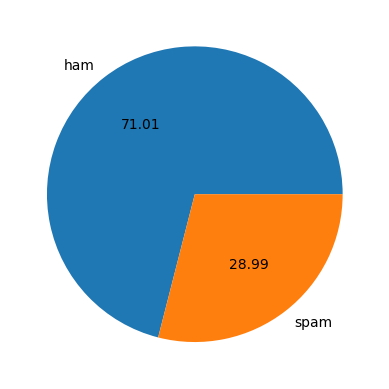

In [27]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Download NLTK resources

In [28]:
import nltk

In [29]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\swapn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [30]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\swapn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Add feature columns

In [37]:
df['num_characters'] = df['text'].apply(len)

In [38]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(str(x))))

In [39]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(str(x))))

In [45]:
df.head()

,Unnamed: 0,target,text,label_num,num_words,num_sentences,num_characters
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,68,3,327
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,24,3,97
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,551,24,2524
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,49,3,414
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,71,3,336


# Stats

In [46]:
print(df[['num_characters','num_words','num_sentences']].describe())

       num_characters    num_words  num_sentences
count     5171.000000  5171.000000    5171.000000
mean      1048.391994   229.181009      13.121253
std       1528.513435   336.487397      27.541637
min         11.000000     2.000000       1.000000
25%        244.000000    52.000000       4.000000
50%        540.000000   122.000000       7.000000
75%       1237.000000   283.500000      15.000000
max      32258.000000  8863.000000    1204.000000


# Compare ham vs spam

In [47]:
print("Ham:\n", df[df['target']==0][['num_characters','num_words','num_sentences']].describe())

Ham:
        num_characters    num_words  num_sentences
count     3672.000000  3672.000000    3672.000000
mean       977.008170   226.239107      11.440904
std       1382.827493   332.179661      24.892442
min         18.000000     3.000000       1.000000
25%        231.750000    51.000000       3.000000
50%        530.000000   124.000000       6.000000
75%       1227.250000   294.000000      13.000000
max      32258.000000  8863.000000    1204.000000


In [48]:
print("Spam:\n", df[df['target']==1][['num_characters','num_words','num_sentences']].describe())

Spam:
        num_characters    num_words  num_sentences
count     1499.000000  1499.000000    1499.000000
mean      1223.256171   236.387592      17.237492
std       1825.986210   346.821249      32.796043
min         11.000000     2.000000       1.000000
25%        283.000000    55.000000       4.000000
50%        576.000000   116.000000       9.000000
75%       1253.500000   244.000000      18.500000
max      22073.000000  3963.000000     693.000000


# Histograms

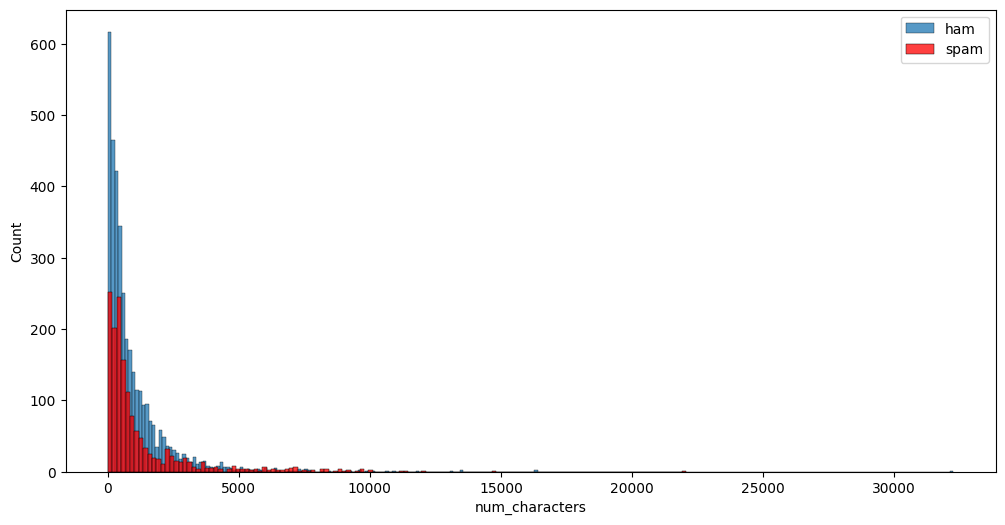

In [54]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'],label="ham")
sns.histplot(df[df['target'] == 1]['num_characters'],color='red',label="spam")
plt.legend()
plt.show()

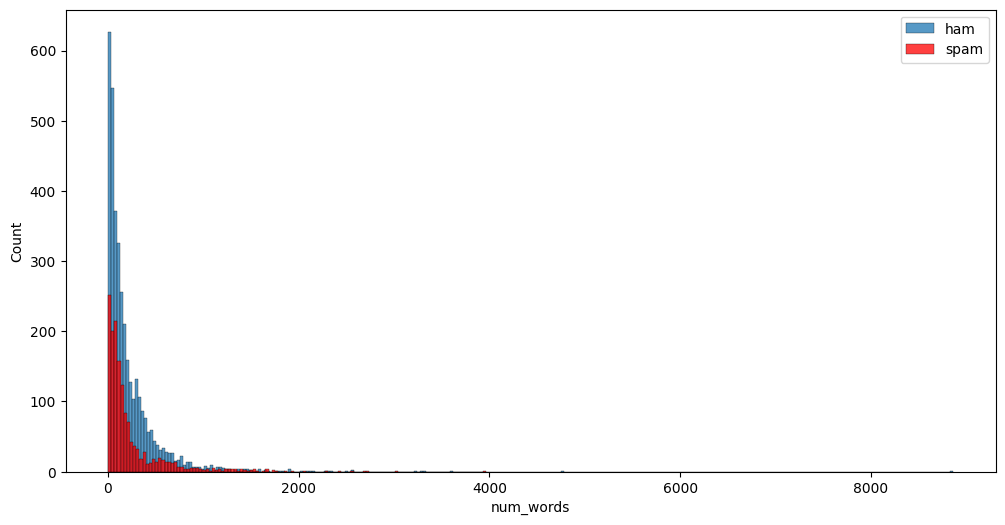

In [55]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'],label="ham")
sns.histplot(df[df['target'] == 1]['num_words'],color='red',label="spam")
plt.legend()
plt.show()

# Correlation heatmap

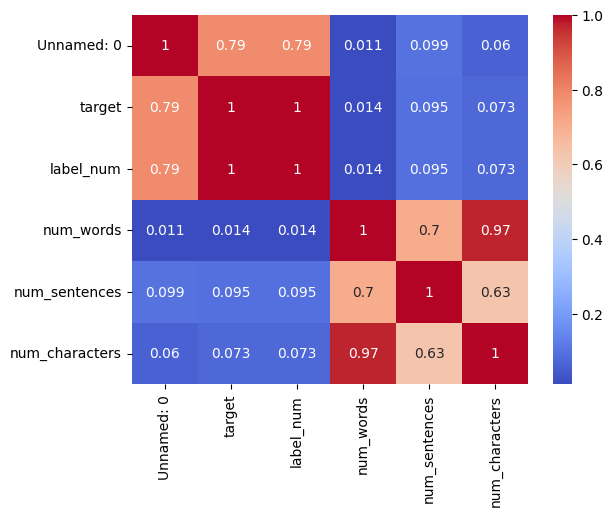

In [56]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.show()

# Text Preprocessing

In [57]:
from nltk.corpus import stopwords

In [58]:
from nltk.stem.porter import PorterStemmer

In [59]:
import re

In [60]:
ps = PorterStemmer()

In [61]:
def transform_text(text):
    # Clean special tokens
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)        # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)        # remove email addresses
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags
    
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [63]:
df['transformed_text'] = df['text'].apply(transform_text)

In [64]:
df.head()

,Unnamed: 0,target,text,label_num,num_words,num_sentences,num_characters,transformed_text
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,68,3,327,subject enron methanol meter 988291 follow not...
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,24,3,97,subject hpl nom januari 9 2001 see attach file...
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,551,24,2524,subject neon retreat ho ho ho around wonder ti...
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,49,3,414,subject photoshop window offic cheap main tren...
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,71,3,336,subject indian spring deal book teco pvr reven...


# WordClouds

In [65]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

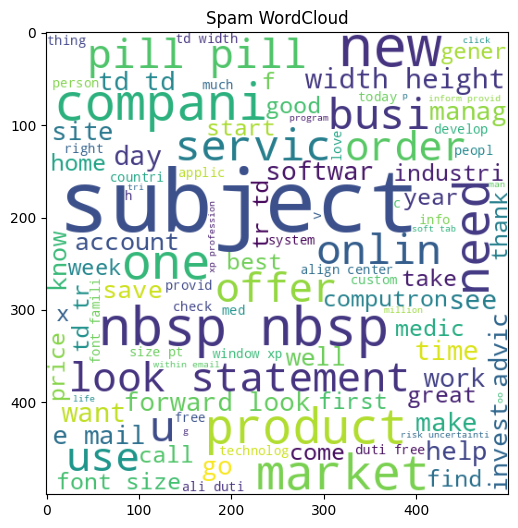

In [66]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title("Spam WordCloud")
plt.show()

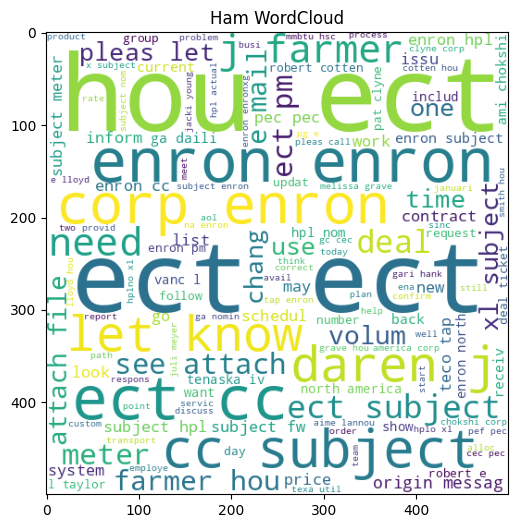

In [67]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title("Ham WordCloud")
plt.show()

# Top words in spam

In [68]:
ham_corpus = []

In [69]:
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
word_freq = pd.DataFrame(Counter(ham_corpus).most_common(30))

In [70]:
word_freq.columns = ['word', 'count']

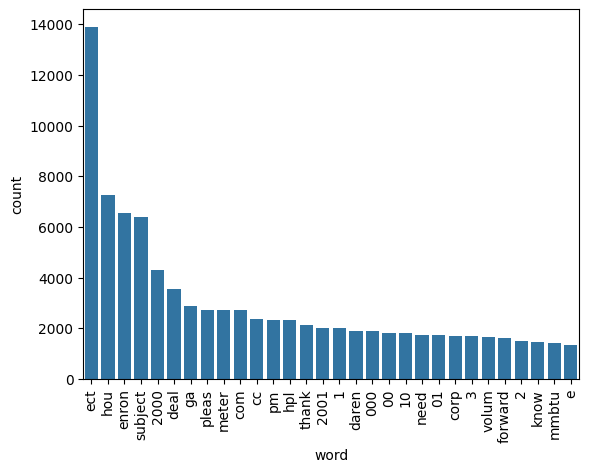

In [71]:
sns.barplot(x="word", y="count", data=word_freq)
plt.xticks(rotation=90)
plt.show()

# Model Building

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
tfidf = TfidfVectorizer(max_features=3000)

In [74]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [75]:
y = df['target'].values

In [76]:
X.shape, y.shape

((5171, 3000), (5171,))

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Try classifiers

In [79]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB

In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
from sklearn.svm import SVC

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

In [85]:
from xgboost import XGBClassifier

In [86]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [88]:
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [89]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [90]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    return accuracy,precision

In [91]:
accuracy_scores = []
precision_scores = []

In [92]:
for name,clf in clfs.items():
    acc,prec = train_classifier(clf, X_train,y_train,X_test,y_test)
    print(f"For {name}: Accuracy={acc:.4f}, Precision={prec:.4f}")
    accuracy_scores.append(acc)
    precision_scores.append(prec)

For SVC: Accuracy=0.9826, Precision=0.9532
For KN: Accuracy=0.9739, Precision=0.9679
For NB: Accuracy=0.9459, Precision=0.8652
For DT: Accuracy=0.8415, Precision=0.6457
For LR: Accuracy=0.9691, Precision=0.9269
For RF: Accuracy=0.9778, Precision=0.9555


C:\Users\swapn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For AdaBoost: Accuracy=0.9633, Precision=0.9088
For BgC: Accuracy=0.9546, Precision=0.9007
For ETC: Accuracy=0.9816, Precision=0.9530
For GBDT: Accuracy=0.9401, Precision=0.9039
For xgb: Accuracy=0.9729, Precision=0.9251


In [93]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
print(performance_df)

   Algorithm  Accuracy  Precision
1         KN  0.973913   0.967857
5         RF  0.977778   0.955479
0        SVC  0.982609   0.953177
8        ETC  0.981643   0.953020
4         LR  0.969082   0.926910
10       xgb  0.972947   0.925081
6   AdaBoost  0.963285   0.908795
9       GBDT  0.940097   0.903915
7        BgC  0.954589   0.900662
2         NB  0.945894   0.865204
3         DT  0.841546   0.645688


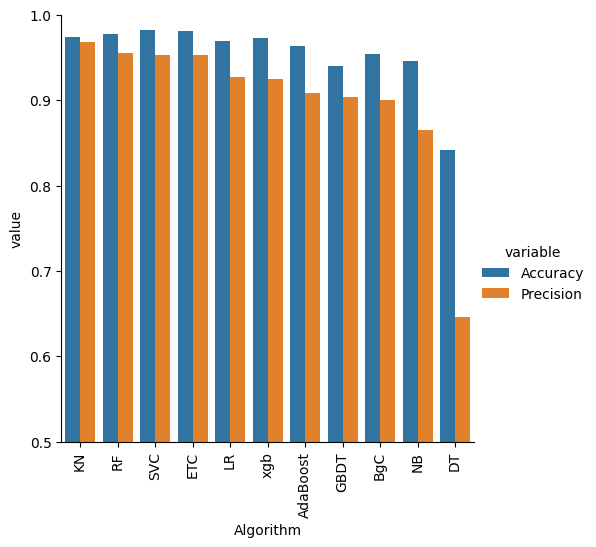

In [94]:
sns.catplot(x='Algorithm',y='value',hue='variable',
            data=pd.melt(performance_df,id_vars="Algorithm"), kind='bar', height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

# Save Best Model Pipeline

In [95]:
import pickle
from sklearn.pipeline import Pipeline

In [96]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000)),
    ('model', MultinomialNB())
])

In [97]:
pipeline.fit(df['transformed_text'], df['target'])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=3000)),
                ('model', MultinomialNB())])

In [98]:
pickle.dump(pipeline, open('spam_classifier.pkl', 'wb'))